# Advection-Diffusion Equation

The advection-diffusion equation models the transport of a scalar $T$ by a velocity field $c$ while simultaneously diffusing:

$$\frac{\partial T}{\partial t} + c\,\frac{\partial T}{\partial x} = D\,\frac{\partial^2 T}{\partial x^2}$$

The balance between advection and diffusion is characterised by the Péclet number $Pe = cL/D$. At high $Pe$ the solution is advection-dominated and a sharp front is preserved; at low $Pe$ diffusion smooths it out.

We use periodic BCs and track a Gaussian pulse advecting to the right.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
from upde import PDE, PDESystem, AdvectionDiffusion

Péclet number Pe = 20


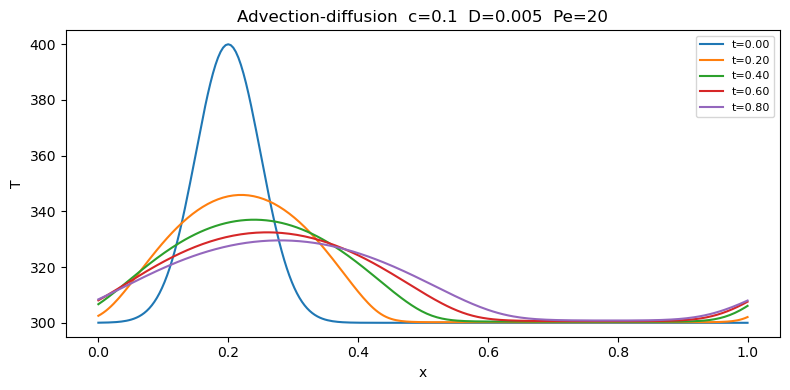

In [31]:
from upde import PDE, PDESystem, AdvectionDiffusion
x   = np.linspace(0, 1, 256)
c   = 0.1    # advection speed
D   = 0.005  # diffusivity lambda x,T: D*(1 + 0.1*(T - T0))
T0 = 300
Pe  = c * 1.0 / D
print(f'Péclet number Pe = {Pe:.0f}')

eq = AdvectionDiffusion('T', x=x, velocity=c, diffusivity = lambda x,T: D*(1 + 0.1*(T - T0)))
eq.add_source(expr=lambda x, T: 1 + 0.1*np.exp(-((x - 0.6)**2) / 0.005))
eq.set_bc(kind='periodic')
eq.set_ic(300 + 100*np.exp(-((x - 0.2)**2) / 0.005))

sol = eq.solve(t_span=(0, 0.8), method='BDF',
                            t_eval=np.linspace(0, 0.8, 5),
                            rtol=1e-4, atol=1e-6)

fig, ax = plt.subplots(figsize=(8, 4))
for k, t in enumerate(sol.t):
    ax.plot(x, sol.T[:, k], label=f't={t:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('T')
ax.set_title(f'Advection-diffusion  c={c}  D={D}  Pe={Pe:.0f}')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
